In [1]:
import os
import random
import pandas as pd
import json


# Mount to google drive
# from google.colab import drive
# drive.mount('/content/drive')

# Change it to your google drive path where this notebook located.
drive_path = '/Users/samyiin/Projects/ZipfLawAnalysis'
os.chdir(drive_path)

In [2]:
# @title Duplicated Code
def store_or_read(file_path, data=None):
    """
    Store a list to a file if it doesn't exist, or read it if it exists.
    
    Parameters:
        file_path (str): Path to the JSON file.
        data (list): List to store if the file doesn't exist. Defaults to None.
        
    Returns:
        list: The list read from the file or the data written to it.
    """
    if os.path.exists(file_path):
        # File exists, read the list
        with open(file_path, 'r') as file:
            stored_data = json.load(file)
        print("File exists. Data read from file.")
        return stored_data
    else:
        # File doesn't exist, write the provided data
        if data is None:
            raise ValueError("File does not exist, and no data provided to write.")
        with open(file_path, 'w') as file:
            json.dump(data, file)
        print("File does not exist. Data written to file.")
        return data

# Add the country to users
So far we separate the map function of LLM and geopy, what happened is we first used geopy to identify countries, and then we use LLM to identify the ones that geopy failed to identify. 

In [3]:
dic_LLM_location_to_country_file_path = "Database/MapLocationToCountry/dic_LLM_processed_location_to_country.json"
dic_LLM_location_to_country = store_or_read(dic_LLM_location_to_country_file_path, data=None)

dic_geo_location_to_country_file_path = "Database/MapLocationToCountry/dic_geo_location_to_country.json"
dic_geo_location_to_country = store_or_read(dic_geo_location_to_country_file_path, data=None)


dic_location_to_country = dic_geo_location_to_country 
dic_location_to_country.update(dic_LLM_location_to_country)

# load the users
df_users = pd.read_csv("GatherData/Filter_1_Parallel/Results/users_filter_1.csv")
df_users['country'] = df_users['location'].map(dic_location_to_country)
df_users.to_csv(f'GatherData/Filter_2_DecypherLocation/Results/users_filter_2.csv', index=False)

File exists. Data read from file.
File exists. Data read from file.


In [4]:
df_users

,login,id,type,site_admin,name,company,blog,location,email,hireable,bio,twitter_username,public_repos,public_gists,followers,following,created_at,updated_at,country
0,Adilbous,44177559,User,False,Adil Bousfiha,NaN,https://medium.com/@adilbousfiha,"Paris, France",adil.bousfiha@student.ecp.fr,NaN,Data Scientist & Biomedical Engineer \r\n#Cent...,NaN,4,0,7,5,2018-10-15T19:32:14Z,2021-01-02T17:34:27Z,France
1,ArjunSahlot,44180430,User,False,Arjun,"@megalodon-chess, @medilocus, @Spatial-Innovat...",NaN,"Neovim, Tmux",iarjun.sahlot@gmail.com,NaN,A high school senior extremely interested in c...,NaN,85,8,30,59,2018-10-15T22:03:32Z,2024-10-30T08:58:55Z,Unknown
2,Ascensiony,44149141,User,False,Abhishek Yadav,IIITS,NaN,India,yadavabhishek0807@gmail.com,True,NaN,Abhishek0807,43,0,3,18,2018-10-15T01:22:11Z,2023-11-15T22:56:21Z,India
3,CrissUD,44172561,User,False,Cristian Felipe Patiño Caceres,Universidad Distrital Francisco Jose de Caldas,NaN,Colombia,cristian.patino@mercadolibre.com.co,NaN,NaN,NaN,60,0,83,9,2018-10-15T16:14:53Z,2023-10-25T19:09:50Z,Colombia
4,DeeeU,44154891,User,False,Deee_U,NaN,NaN,Japan,jac8for@gmail.com,NaN,NaN,Deee_U_,20,0,3,5,2018-10-15T06:30:03Z,2024-11-05T12:46:25Z,Japan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
215323,tomcason,4441182,User,False,Tom Cason,NaN,NaN,NaN,tcason@uarts.edu,NaN,NaN,NaN,3,0,1,1,2013-05-15T20:04:14Z,2022-10-24T09:47:35Z,NaN
215324,umbaugh-careev,4439220,User,False,John Umbaugh,CareEvolution,NaN,"Ann Arbor, MI",umbaugh@careevolution.com,NaN,NaN,NaN,3,0,1,0,2013-05-15T15:39:09Z,2024-08-12T13:53:15Z,United States
215325,vnStrawHat,4435695,User,False,NaN,NaN,NaN,NaN,thanhtrung9h@gmail.com,NaN,NaN,NaN,13,2,12,0,2013-05-15T08:26:15Z,2024-11-09T13:55:30Z,NaN
215326,westernfront,4433236,User,False,NaN,NaN,NaN,NaN,westernfront@163.com,NaN,NaN,NaN,10,0,2,0,2013-05-15T01:57:04Z,2024-07-08T05:03:47Z,NaN


# Statistics

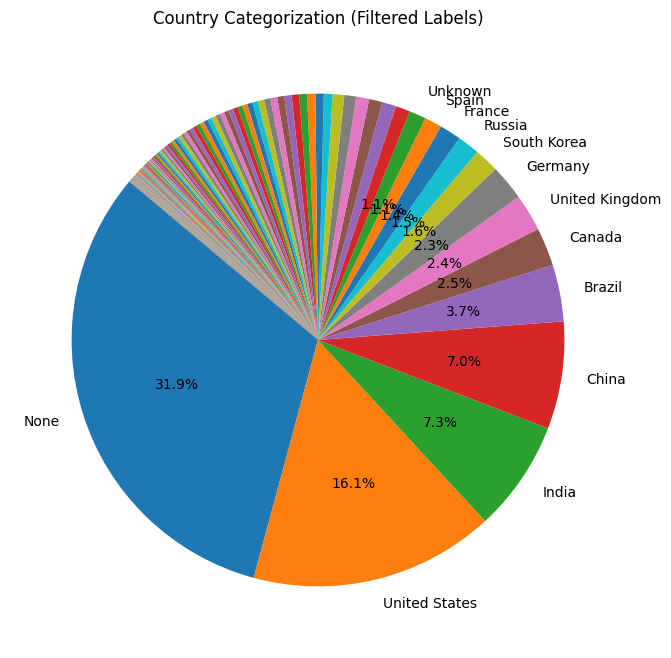

In [6]:
import pandas as pd
import matplotlib.pyplot as plt


# Categorization function
def categorize_country(row):
    if pd.isna(row):
        return 'None'
    countries = set(row.split(' & '))
    if 'United States' in countries and 'China' in countries:
        return 'United States & China & other(s)' 
    elif 'United States' in countries:
        return 'United States & other(s)' if len(countries) > 1 else 'United States'
    elif 'China' in countries:
        return 'China & other(s)' if len(countries) > 1 else 'China'
    elif '&' in row:
        return 'Multi-country (no America/China)'
    else:
        return row

# Apply categorization
df_for_plot = df_users['country'].apply(categorize_country)

# Count categories
category_counts = df_for_plot.value_counts()

# This following whole chunk of chart is to not show anything with lower percentage. 
def pi_chart_with_significance(category_counts, threshold_percentage, show_ledgen):
    # Calculate percentages
    total = category_counts.sum()
    category_percentages = (category_counts / total) * 100

    # Set a threshold for label display
    labels = [
        f"{cat}" if perc >= threshold_percentage else ""  # Show the category name only if it's above the threshold
        for cat, perc in zip(category_counts.index, category_percentages)
    ]

    # Plotting the pie chart
    plt.figure(figsize=(10, 8))
    wedges, texts, autotexts = plt.pie(
        category_counts,
        labels=labels,
        autopct=lambda p: f"{p:.1f}%" if p >= threshold_percentage else "",  # Show percentage only if it's above the threshold
        startangle=140,
        textprops=dict(color="black")
    )

    if show_ledgen:
        # Add a legend for all categories
        plt.legend(
            wedges,
            category_counts.index,
            title="Categories",
            loc="center left",
            bbox_to_anchor=(1, 0, 0.5, 1)
        )

    plt.title('Country Categorization (Filtered Labels)')
    plt.show()

pi_chart_with_significance(category_counts, 1, False)

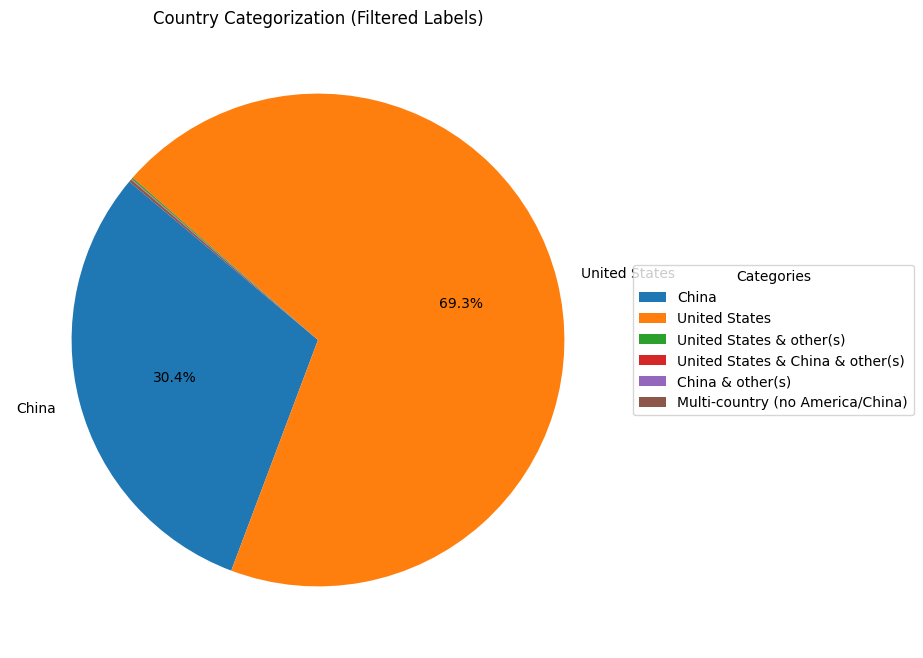

In [7]:
related_catagory_count = category_counts[['China', 'United States', 'United States & other(s)', 'United States & China & other(s)', 'China & other(s)', 'Multi-country (no America/China)']]
# Plotting the pie chart
pi_chart_with_significance(related_catagory_count, 1, True)

In [8]:
related_catagory_count

country
China                               15170
United States                       34588
United States & other(s)               49
United States & China & other(s)       13
China & other(s)                       17
Multi-country (no America/China)       88
Name: count, dtype: int64